In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
import sklearn
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [ ]:
df = pd.read_csv('DailyDelhiClimateTest.csv')

In [ ]:
daily_data = df['meantemp']

In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [ ]:
train = daily_data[:int(len(daily_data) * 0.8)]
test = daily_data[int(len(daily_data) * 0.8):]

In [ ]:
fitted_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=30
).fit()
test_predictions = fitted_model.forecast(len(test))

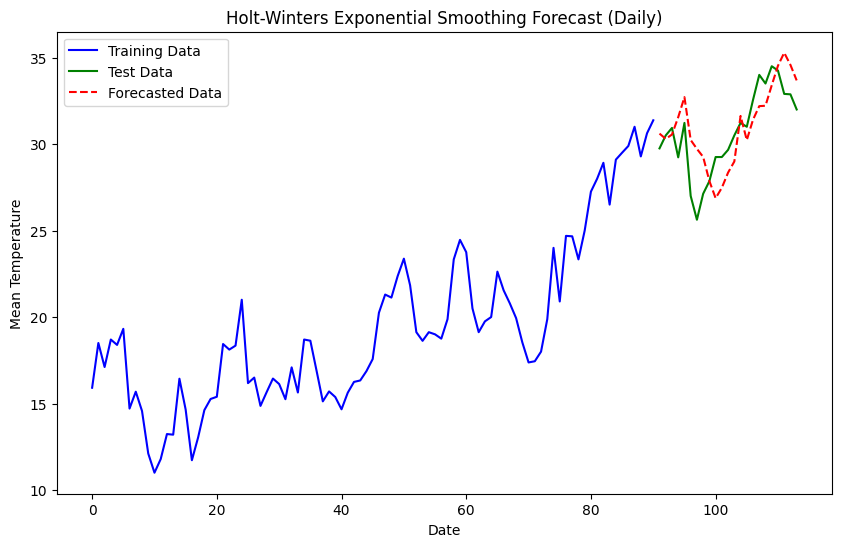

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Test Data', color='green')
plt.plot(test.index, test_predictions, label='Forecasted Data', color='red', linestyle='--')
plt.title('Holt-Winters Exponential Smoothing Forecast (Daily)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature')
plt.legend()
plt.show()

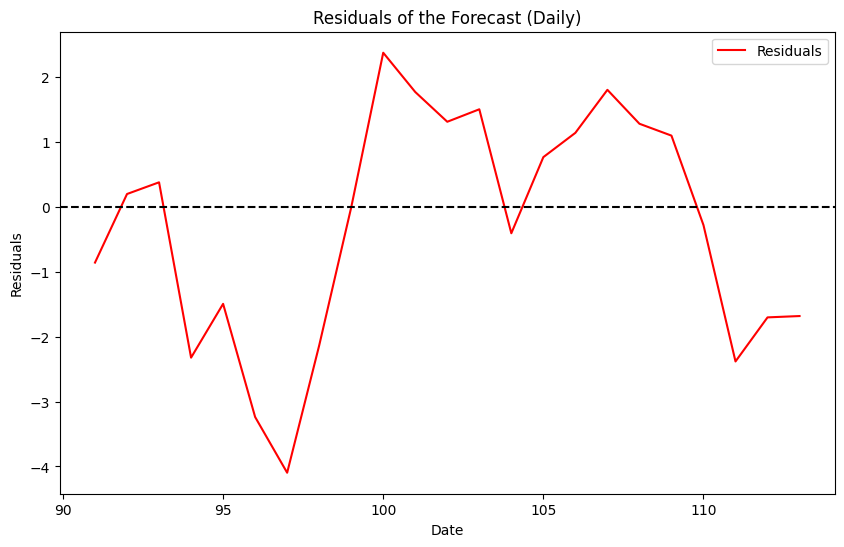

In [ ]:
residuals = test - test_predictions

plt.figure(figsize=(10, 6))
plt.plot(test.index, residuals, label='Residuals', color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals of the Forecast (Daily)')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.legend()
plt.show()

In [ ]:
rmse = mean_squared_error(test, test_predictions, squared=False)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
mse = mean_squared_error(test, test_predictions, squared=True)

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
r2 = r2_score(test, test_predictions)

In [ ]:
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Root Mean Squared Error (RMSE): 1.7793375038903605
Mean Squared Error (MSE): 3.1660419527507786
R-squared (R2): 0.4393010012913262
